In [72]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib
import scipy.constants as sc

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)
import Gibbs
importlib.reload(Gibbs)

<module 'Gibbs' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/BasicEulerNN/Gibbs.py'>

## Procedure
1. Load data from the SPM experiments
2. Try the `Gibbs.py` to see what happens
3. Compare $G$ for the positive and negative electrode 
4. Implement the $\omega$ part in cases there are problems 
5. Examine the end of the paper, where they tie it all together to see if there's a way to improve.

### 1. Loading data
I chose to load the GRF data 

(1000,) (1000,) (1000,) (1000,) (1000,) (1000,) (1000,)


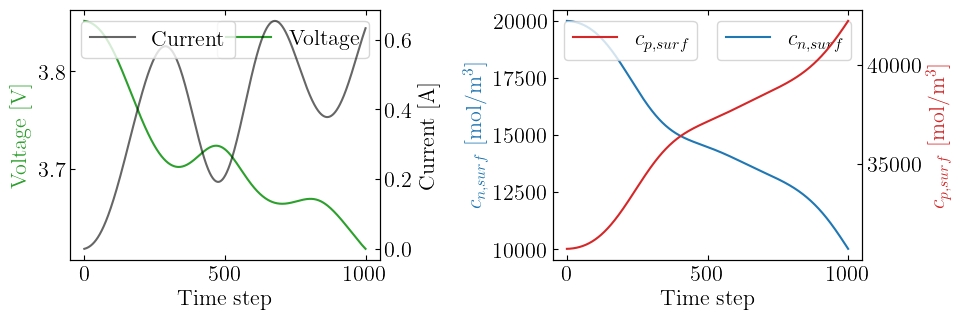

In [62]:
sol, mod, params = sim_PyBaMM.simulate_DC(0.5)
def load_data(path):
    data = np.load(path)
    return data['I'], data['dI'], data['V'], data['cn'], data['cn_dot'], data['cp'], data['cp_dot'], data['valid']

I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('Euler_data/data_GRF_SPM.npz')

N_pick = 1000
I = I[valid].ravel()[:N_pick]
dI = dI[valid].ravel()[:N_pick]
V = V[valid].ravel()[:N_pick]
cn = cn[valid].ravel()[:N_pick]
cn_dot = cn_dot[valid].ravel()[:N_pick]
cp = cp[valid].ravel()[:N_pick]
cp_dot = cp_dot[valid].ravel()[:N_pick]

print(I.shape, dI.shape, V.shape, cn.shape, cn_dot.shape, cp.shape, cp_dot.shape)

f,ax = plt.subplots(1,2, figsize = (10,3.5))
axt1 = ax[0].twinx()
axt1.plot(I,'k', label = 'Current',alpha = 0.6)
ax[0].plot(V,'tab:green', label = 'Voltage')
ax[0].legend(loc = 'upper right')
axt1.legend(loc = 'upper left')
ax[0].set_xlabel('Time step')
ax[0].set_ylabel('Voltage [V]', color = 'tab:green')
axt1.set_ylabel('Current [A]', color = 'k')

axt2 = ax[1].twinx()
ax[1].plot(cn,'tab:blue', label = '$c_{n,surf}$ ')
axt2.plot(cp,'tab:red', label = '$c_{p,surf}$ ')
ax[1].set_xlabel('Time step')
ax[1].set_ylabel('$c_{n,surf}$ [mol/m$^3$]', color = 'tab:blue')
axt2.set_ylabel('$c_{p,surf}$ [mol/m$^3$]', color = 'tab:red')
ax[1].legend(loc = 'upper right')
axt2.legend(loc = 'upper left')
plt.tight_layout()

### 2. Try the `Gibbs.py` file

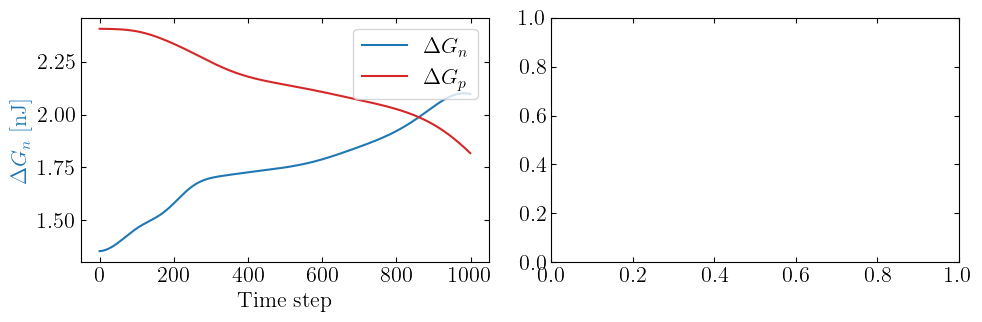

In [ ]:

dG_n = Gibbs.dGdt_am(cn,params =params, which_c = 'n') * 1e9
dG_p = Gibbs.dGdt_am(cp,params =params, which_c = 'p') * 1e9

f, ax = plt.subplots(1,2, figsize = (10,3.5))
ax[0].plot(dG_n,'tab:blue', label = r'$\Delta G_n$')
ax[0].set_xlabel('Time step')
ax[0].set_ylabel(r'$\Delta G_n$ [nJ]', color = 'tab:blue')
ax[0].plot(dG_p,'tab:red', label = r'$\Delta G_p$')
ax[0].set_xlabel('Time step')
ax[0].set_ylabel(r'$\Delta G_n$ [nJ]', color = 'tab:blue')
ax[0].legend(loc = 'upper right')
plt.tight_layout()

Okay, this does not say that much. I think I'll find $$G=-4\pi R^2F\int_0^R\bigg[\int U_{eq}(c(r))\,dc\bigg]\,dr$$